# Figure A1: Robustness to Non-Gaussian Noise (Supplementary)

This notebook tests the robustness of the phase transition theory to violations of the Gaussian noise assumption by comparing multiple heavy-tailed and heteroskedastic distributions.

**Figure layout (3 panels):**
- (a) Phase transition curves R_x^2 for each noise type
- (b) Phase transition curves R_y^2 for each noise type
- (c) Theory deviation (MAE) vs excess kurtosis

In [6]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from tqdm.notebook import tqdm

from src import (
    ModelParams, generate_data_non_gaussian, pls_svd, compute_overlaps,
    theoretical_overlaps, run_multiple_trials_non_gaussian, _run_non_gaussian_worker
)

# ICML-compatible styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

np.random.seed(42)

## 1. Define Noise Distributions
| Distribution | Variance | Excess Kurtosis | Notes |
|-------------|----------|-----------------|-------|
| Gaussian N(0,1) | 1 | 0 | Theory baseline |
| Student-t(5) | 1 (scaled) | 6 | Moderate heavy tails |
| Student-t(4.5) | 1 (scaled) | 12 | Heavy tails |
| Student-t(3) | 1 (scaled) | ∞ | Infinite kurtosis |
| Laplace(0, 1/√2) | 1 | 3 | Different tail decay |
| Heteroskedastic | ~1 (avg) | varies | Non-i.i.d. variance |


In [7]:
# Noise distribution metadata
# For Student-t: excess kurtosis = 6/(df-4) for df > 4
NOISE_TYPES = {
    'gaussian': {
        'label': 'Gaussian',
        'excess_kurtosis': 0,
        'color': 'C0',
        'marker': 'o',
    },
    't5': {
        'label': 'Student-t (df=5)',
        'excess_kurtosis': 6,  # 6/(5-4) = 6
        'color': 'C1',
        'marker': 's',
    },
    't4.5': {
        'label': 'Student-t (df=4.5)',
        'excess_kurtosis': 12,  # 6/(4.5-4) = 12
        'color': 'C2',
        'marker': '^',
    },
    't3': {
        'label': 'Student-t (df=3)',
        'excess_kurtosis': np.inf,  # undefined for df <= 4
        'color': 'C5',
        'marker': 'D',
    },
    'laplace': {
        'label': 'Laplace',
        'excess_kurtosis': 3,
        'color': 'C3',
        'marker': 'v',
    },
    'heteroskedastic': {
        'label': 'Heteroskedastic',
        'excess_kurtosis': 0.6,  # Approximate for uniform-scaled Gaussian
        'color': 'C4',
        'marker': 'd',
    },
}

print("Noise distributions to test:")
for name, info in NOISE_TYPES.items():
    kurt = info['excess_kurtosis']
    kurt_str = f"{kurt:.1f}" if np.isfinite(kurt) else "∞"
    print(f"  {info['label']:25s} - Excess kurtosis: {kurt_str}")

Noise distributions to test:
  Gaussian                  - Excess kurtosis: 0.0
  Student-t (df=5)          - Excess kurtosis: 6.0
  Student-t (df=4.5)        - Excess kurtosis: 12.0
  Student-t (df=3)          - Excess kurtosis: ∞
  Laplace                   - Excess kurtosis: 3.0
  Heteroskedastic           - Excess kurtosis: 0.6


## 2. Experiment Setup

In [8]:
# Fixed parameters
N = 1000
Dx = 200
Dy = 150
mx = my = 0.3
n_trials = 100

# Compute theta_crit
alpha_x = N / Dx
alpha_y = N / Dy
rho = (1 - mx) * (1 - my)
theta_crit = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho))

# Theta sweep
theta_values = np.linspace(0.6 * theta_crit, 2.0 * theta_crit, 25)

print(f"Parameters:")
print(f"  N={N}, Dx={Dx}, Dy={Dy}")
print(f"  mx={mx}, my={my}, ρ={(1-mx)*(1-my):.2f}")
print(f"  θ_crit = {theta_crit:.4f}")
print(f"  θ range: [{theta_values[0]:.3f}, {theta_values[-1]:.3f}]")
print(f"  n_trials = {n_trials}")

Parameters:
  N=1000, Dx=200, Dy=150
  mx=0.3, my=0.3, ρ=0.49
  θ_crit = 0.5945
  θ range: [0.357, 1.189]
  n_trials = 100


## 3. Run Experiments

In [9]:
# Check for cached results
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
cache_file = os.path.join(results_dir, 'figA1_results.pkl')

if os.path.exists(cache_file):
    print("Loading cached results...")
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)
    print("Done!")
else:
    print("Running experiments...")
    all_results = {}
    
    for noise_type in NOISE_TYPES.keys():
        print(f"\n  Processing {NOISE_TYPES[noise_type]['label']}...")
        results = []
        
        # Prepare arguments for parallel execution
        args_list = []
        for theta in theta_values:
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx, 'my': my}
            args_list.append((params_dict, noise_type, n_trials, theta, theta_crit))
        
        # Run in parallel
        with Pool() as pool:
            results = list(tqdm(pool.imap(_run_non_gaussian_worker, args_list),
                               total=len(args_list), desc=f"    θ sweep"))
        
        all_results[noise_type] = results
    
    # Cache results
    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("\nResults cached!")

Running experiments...

  Processing Gaussian...


    θ sweep:   0%|          | 0/25 [00:00<?, ?it/s]


  Processing Student-t (df=5)...


    θ sweep:   0%|          | 0/25 [00:00<?, ?it/s]


  Processing Student-t (df=4.5)...


...


  Processing Laplace...


    θ sweep:   0%|          | 0/25 [00:00<?, ?it/s]


  Processing Heteroskedastic...


    θ sweep:   0%|          | 0/25 [00:00<?, ?it/s]


Results cached!


## 4. Create Publication Figure

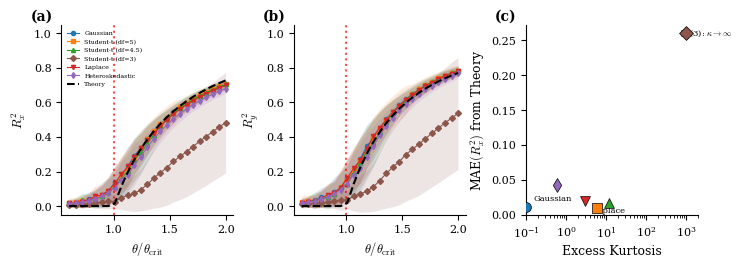


Figure saved: ../figures/figA1_robustness_analysis.pdf


In [11]:
fig = plt.figure(figsize=(7.0, 2.5))
gs = gridspec.GridSpec(1, 3, wspace=0.35,
                       left=0.07, right=0.98, bottom=0.16, top=0.92)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# --- Panel (a): R_x² phase transition curves ---
for noise_type, info in NOISE_TYPES.items():
    results = all_results[noise_type]
    theta_norm = [r['theta_norm'] for r in results]
    rx2_mean = [r['Rx2_pls_mean'] for r in results]
    rx2_std = [r['Rx2_pls_std'] for r in results]
    
    ax_a.plot(theta_norm, rx2_mean,
              marker=info['marker'], markersize=3, linewidth=0.8,
              color=info['color'], label=info['label'])
    ax_a.fill_between(theta_norm,
                      np.array(rx2_mean) - np.array(rx2_std),
                      np.array(rx2_mean) + np.array(rx2_std),
                      color=info['color'], alpha=0.15, linewidth=0)

# Theory (Gaussian)
results_gauss = all_results['gaussian']
ax_a.plot([r['theta_norm'] for r in results_gauss],
          [r['Rx2_theory'] for r in results_gauss],
          'k--', linewidth=1.5, label='Theory', zorder=10)

ax_a.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_a.set_ylabel(r'$R_x^2$')
ax_a.set_ylim([-0.05, 1.05])
ax_a.legend(loc='upper left', frameon=False, fontsize=4.5, ncol=1)
ax_a.text(-0.18, 1.08, '(a)', transform=ax_a.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (b): R_y² phase transition curves ---
for noise_type, info in NOISE_TYPES.items():
    results = all_results[noise_type]
    theta_norm = [r['theta_norm'] for r in results]
    ry2_mean = [r['Ry2_pls_mean'] for r in results]
    ry2_std = [r['Ry2_pls_std'] for r in results]
    
    ax_b.plot(theta_norm, ry2_mean,
              marker=info['marker'], markersize=3, linewidth=0.8,
              color=info['color'], label=info['label'])
    ax_b.fill_between(theta_norm,
                      np.array(ry2_mean) - np.array(ry2_std),
                      np.array(ry2_mean) + np.array(ry2_std),
                      color=info['color'], alpha=0.15, linewidth=0)

# Theory (Gaussian)
ax_b.plot([r['theta_norm'] for r in results_gauss],
          [r['Ry2_theory'] for r in results_gauss],
          'k--', linewidth=1.5, label='Theory', zorder=10)

ax_b.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_b.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_b.set_ylabel(r'$R_y^2$')
ax_b.set_ylim([-0.05, 1.05])
ax_b.text(-0.18, 1.08, '(b)', transform=ax_b.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (c): MAE vs Excess Kurtosis ---
mae_values = []
kurtosis_values = []
kurtosis_plot_values = []
labels = []

for noise_type, info in NOISE_TYPES.items():
    results = all_results[noise_type]
    
    # Compute MAE (only for supercritical regime to avoid trivial zeros)
    rx2_emp = np.array([r['Rx2_pls_mean'] for r in results])
    rx2_theory = np.array([r['Rx2_theory'] for r in results])
    theta_norm = np.array([r['theta_norm'] for r in results])
    
    # Focus on supercritical regime (θ/θ_crit > 1.1)
    mask = theta_norm > 1.1
    if mask.sum() > 0:
        mae = np.mean(np.abs(rx2_emp[mask] - rx2_theory[mask]))
    else:
        mae = np.nan
    
    kurt = info['excess_kurtosis']
    if np.isfinite(kurt):
        # For log scale, use small offset for kurtosis = 0 (Gaussian)
        kurt_plot = max(kurt, 0.1) if kurt == 0 else kurt
        kurtosis_values.append(kurt)
        kurtosis_plot_values.append(kurt_plot)
        mae_values.append(mae)
        labels.append(info['label'])
        ax_c.scatter(kurt_plot, mae, s=50, c=info['color'], marker=info['marker'],
                    edgecolors='black', linewidths=0.5, zorder=5)
    else:
        # t3 has infinite kurtosis, plot at right edge with arrow
        # Use log scale, so plot at a high value (e.g., 1000)
        ax_c.scatter(1000, mae, s=50, c=info['color'], marker=info['marker'],
                    edgecolors='black', linewidths=0.5, zorder=5)
        ax_c.annotate('', xy=(1200, mae), xytext=(1000, mae),
                     arrowprops=dict(arrowstyle='->', color=info['color'], lw=1.5))

# Add labels next to points (only for a few key distributions to avoid clutter)
for kurt_plot, mae, label in zip(kurtosis_plot_values, mae_values, labels):
    if label == 'Gaussian':
        ax_c.annotate(label, (kurt_plot, mae), xytext=(5, 5),
                     textcoords='offset points', fontsize=6)
    elif label == 'Laplace':
        ax_c.annotate(label, (kurt_plot, mae), xytext=(5, -8),
                     textcoords='offset points', fontsize=6)

ax_c.set_xlabel('Excess Kurtosis')
ax_c.set_ylabel(r'MAE$(R_x^2)$ from Theory')
ax_c.set_xscale('log')
ax_c.set_xlim([0.1, 2000])
ax_c.set_ylim([0, None])
ax_c.text(-0.18, 1.08, '(c)', transform=ax_c.transAxes,
          fontsize=10, fontweight='bold', va='top')

# Add annotation for t3 at infinity
if len(mae_values) > 0:
    # Find t3 result
    t3_mae = None
    for noise_type, info in NOISE_TYPES.items():
        if info['label'] == 'Student-t (df=3)':
            results = all_results[noise_type]
            rx2_emp = np.array([r['Rx2_pls_mean'] for r in results])
            rx2_theory = np.array([r['Rx2_theory'] for r in results])
            theta_norm = np.array([r['theta_norm'] for r in results])
            mask = theta_norm > 1.1
            if mask.sum() > 0:
                t3_mae = np.mean(np.abs(rx2_emp[mask] - rx2_theory[mask]))
            break
    if t3_mae is not None:
        ax_c.text(1000, t3_mae, r't(3): $\kappa\to\infty$',
                  fontsize=6, ha='left', va='center')

plt.savefig('../figures/figA1_robustness_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: ../figures/figA1_robustness_analysis.pdf")